<a href="https://colab.research.google.com/github/Alezgo-ui/Project_ConnectaTel/blob/main/Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [ ]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print('valores nulos')
print(users.isna().sum())
print()
print('proporcion')
print(users.isna().mean())
users.isna().mean().to_frame(name='Porcentaje Nulos').style.format('{:.0%}')

valores nulos
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

proporcion
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


,Porcentaje Nulos
user_id,0%
first_name,0%
last_name,0%
age,0%
city,12%
reg_date,0%
plan,0%
churn_date,88%


In [ ]:
# cantidad de nulos para usage
print('valores nulos')
print(usage.isna().sum())
print()
print('proporcion')
print(usage.isna().mean())
usage.isna().mean().to_frame(name='Porcentaje Nulos').style.format('{:.0%}')

valores nulos
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

proporcion
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


,Porcentaje Nulos
id,0%
user_id,0%
type,0%
date,0%
duration,55%
length,45%


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

 ---

**Para el data frame de users:**

`city: `No la eliminaría. Al ser un 12%, intentaría imputarla para no perder el resto de los datos de esa fila. Si tuviéramos la dirección IP o el código postal en otra tabla, intentaría un merge para rescatar los nombres de las ciudades reales.

`churn_date: `Suele significar "Fecha de cancelación de la cuenta". La dejo tal cual, o creo una variable bandera (booleana).


**Para el data frame usage**

`duration y length: `Ambas columnas tienen un volumen de nulos masivo (rango 30% - 60%), lo cual es un síntoma de un problema sistémico en la recolección de datos. No imputaria ciegamente duration ni length.
Filtraría el DataFrame por la columna type para ver si los nulos se concentran en un solo tipo de interacción.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users
print()
display(users.head(1))
print()
# 1. ¿Cuántos usuarios únicos tenemos en total?
print("-" * 50)
print('¿Cuántos usuarios únicos tenemos en total?')
usuarios_unicos = users['user_id'].nunique()
total_filas = len(users)
print(f"Total de registros en la tabla: {total_filas}")
print(f"Total de usuarios únicos: {usuarios_unicos}")

# 2. Validación crítica: ¿Existen IDs duplicados?
print("-" * 50)
if usuarios_unicos == total_filas:
    print("✅ Todo en orden: 'user_id' es una llave primaria limpia (sin duplicados).")
else:
    print("⚠️ ¡Atención!: Hay IDs duplicados en la tabla. Necesitamos investigar.")

print()
# 2. Resumen estadistio de age
print('Resumen estadistio de age:')
users['age'].describe()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN



--------------------------------------------------
¿Cuántos usuarios únicos tenemos en total?
Total de registros en la tabla: 4000
Total de usuarios únicos: 4000
--------------------------------------------------
✅ Todo en orden: 'user_id' es una llave primaria limpia (sin duplicados).

Resumen estadistio de age:


count    4000.000000
mean       33.739750
std       123.232257
min      -999.000000
25%        32.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

- La columna `user_id` es una llave unica que identifica al usuario, no podemos hacer uso de describe() porque son variables que no son cuantitativas, en su lugar identifico usuarios unicos y hago conteo de duplicados (si aplica). En este caso no hubo duplicados.
- La columna `age` tiene sentinels ya que hay minimo de -999 aunque la mayoria de los valores tengan senntido la media y la desviacion de alteran por este sentinel debemos reemplazar el valor centinela por NaN de Pandas.

In [ ]:
# explorar columnas numéricas de usage
def explorar_identificadores(df, columnas_a_evaluar):
    """
    Evalúa columnas de ID para verificar valores únicos, duplicados y nulos.
    """
    total_filas = len(df)
    print(f"Total de registros en el DataFrame: {total_filas:,}\n")

    for col in columnas_a_evaluar:
        # Verificar si la columna realmente existe en este DataFrame
        if col not in df.columns:
            print(f"⚠️ La columna '{col}' no existe en este DataFrame.\n")
            continue

        # Hacer los conteos clave
        valores_unicos = df[col].nunique()
        valores_nulos = df[col].isna().sum()

        print(f"📊 Analizando columna: `{col}`")
        print(f"  - Valores únicos encontrados: {valores_unicos:,}")
        print(f"  - Valores nulos (vacíos): {valores_nulos:,}")

        # Validación de duplicados
        if valores_unicos == total_filas:
            print("  - Resultado: ✅ ¡Perfecto! No hay duplicados. Cada fila tiene un ID único.")
        else:
            filas_duplicadas = total_filas - valores_unicos
            print(f"  - Resultado: 🔄 Hay duplicados. Existen {filas_duplicadas:,} valores repetidos.")

        print("-" * 50)

In [ ]:
def explorar_columnas_numericas(df, columnas_a_evaluar):
    """
    Aplica el método .describe() a las columnas numéricas seleccionadas
    y presenta los resultados en una sola tabla limpia.
    """
    # Validar que al menos una columna de la lista exista en el DataFrame
    columnas_validas = [col for col in columnas_a_evaluar if col in df.columns]

    if not columnas_validas:
        print("⚠️ Ninguna de las columnas proporcionadas existe en el DataFrame.")
        return None

    # Aplicamos describe solo a las columnas válidas y transponemos (.T)
    # para que las columnas queden en las filas, facilitando la lectura
    resumen = df[columnas_validas].describe().T

    # Renombrar las columnas del resumen para que estén en español y se entiendan mejor
    resumen = resumen.rename(columns={
        'count': 'Conteo',
        'mean': 'Promedio',
        'std': 'Desv. Estándar',
        'min': 'Mínimo',
        '25%': '25% (Q1)',
        '50%': '50% (Mediana)',
        '75%': '75% (Q3)',
        'max': 'Máximo'
    })

    print(f"📊 Resumen Estadístico de Variables Numéricas:")

    # Retornamos el DataFrame con un formato limpio de 2 decimales
    return resumen.style.format('{:,.2f}')

In [ ]:
display(usage.head(1))

# Definimos la variable con las columnas a evaluar
columnas_usage = ['id', 'user_id']

# Llamamos a la función
explorar_identificadores(usage, columnas_usage)

# Definimos la variable con las columnas numéricas a analizar
columnas_numericas = ['duration', 'length']

# Llamamos a la función (recuerda cambiar 'df2' por el nombre real de tu DataFrame)
explorar_columnas_numericas(usage, columnas_numericas)


,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN


Total de registros en el DataFrame: 40,000

📊 Analizando columna: `id`
  - Valores únicos encontrados: 40,000
  - Valores nulos (vacíos): 0
  - Resultado: ✅ ¡Perfecto! No hay duplicados. Cada fila tiene un ID único.
--------------------------------------------------
📊 Analizando columna: `user_id`
  - Valores únicos encontrados: 3,999
  - Valores nulos (vacíos): 0
  - Resultado: 🔄 Hay duplicados. Existen 36,001 valores repetidos.
--------------------------------------------------
📊 Resumen Estadístico de Variables Numéricas:


,Conteo,Promedio,Desv. Estándar,Mínimo,25% (Q1),50% (Mediana),75% (Q3),Máximo
duration,"17,924.00",5.20,6.84,0.00,1.44,3.50,6.99,120.00
length,"22,104.00",52.13,56.61,0.00,37.00,50.00,64.00,"1,490.00"


- Las columnas `id` y `user_id` `id` en este caso muestra el total de "llamadas" que se realizaron en el data frame, que no haya repetidos en una excelente noticia ya que demuestra que no hay error en la captura de datos. De igual manera el que haya repetidos en `user_id` es totalmente esperado y prueba de que los clientes hacen varias llamadas, algo totalmente esperado y un alivio para el negocio.
- Las columnas `duration` y `length` presentan una distribución asimétrica con un fuerte sesgo a la derecha, ocasionado por usuarios atípicos con interacciones extremadamente largas (ej. length máximo de 1,490). Para análisis de comportamiento promedio, se recomienda utilizar la Mediana (50%) en lugar del Promedio, ya que la mediana refleja de mejor manera la experiencia del usuario típico sin verse afectada por los outliers. Asimismo, se requiere definir la regla de negocio para los valores mínimos de 0.00."

In [ ]:
# explorar columnas categóricas de users
def explorar_columnas_categoricas(df, columnas_a_evaluar):
    """
    Reportes de frecuencia y porcentaje para múltiples columnas categóricas.
    """
    for col in columnas_a_evaluar:
        # Verificar si la columna existe antes de procesar
        if col not in df.columns:
            print(f"⚠️ La columna '{col}' no existe en este DataFrame.\n")
            print("=" * 50 + "\n")
            continue

        # 1. Conteo absoluto y relativo
        frecuencia = df[col].value_counts(dropna=False)
        porcentaje = df[col].value_counts(dropna=False, normalize=True)

        # 2. Combinar en un DataFrame de resumen
        resumen_cat = pd.DataFrame({
            'Frecuencia': frecuencia,
            'Porcentaje': porcentaje
        })

        # 3. Presentación visual
        print(f"🗂️ Distribución de la variable: `{col}`")

        # Usamos display() para que Jupyter renderice la tabla con formato HTML
        # dentro del ciclo for, manteniendo el diseño limpio.
        display(resumen_cat.style.format({
            'Frecuencia': '{:,}',
            'Porcentaje': '{:.1%}'
        }))
        print("\n" + "="*50 + "\n")


In [ ]:
display(users.head(1))
# Definimos las columnas categóricas a evaluar
columnas_user = ['city', 'plan']
# Llamamos a la función
explorar_columnas_categoricas(users, columnas_user)


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN


🗂️ Distribución de la variable: `city`


,Frecuencia,Porcentaje
Bogotá,808,20.2%
CDMX,730,18.2%
Medellín,616,15.4%
nan,469,11.7%
GDL,450,11.2%
Cali,424,10.6%
MTY,407,10.2%
?,96,2.4%




🗂️ Distribución de la variable: `plan`


,Frecuencia,Porcentaje
Basico,"2,595",64.9%
Premium,"1,405",35.1%


- La columna `city` tiene una distrubicion variada con ciudades con mas precencia que otras, sin embargo existen valores nulos (nan) y otro tipo de nulo tambien (?) lo cual demuestra que ademas de estandarizar nombres se debe estandarizar nulos.
- La columna `plan` demuestra que solmente existen 2 planes, basico y premium algo a notar es que hay una cantidad considerable de usuarios premium, algo bueno para el negocio y posibilidad de analisis mas profundo para detectar patrones en estos.

In [ ]:
# explorar columna categórica de usage
display(usage.head(1))
# Definimos las columnas categóricas a evaluar
columnas_usage = ['type']
# Llamamos a la función
explorar_columnas_categoricas(usage, columnas_usage)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN


🗂️ Distribución de la variable: `type`


,Frecuencia,Porcentaje
text,"22,092",55.2%
call,"17,908",44.8%


- La columna `type` presenta 2 variables, text y call las cuales estan distribuidas casi de manera uniforme con text teniendo una ventaja de poco mas del 10%

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
En la columna age y city.
- ¿Qué acción tomarías?
age (Edad): Eliminar el -999 (convertir NaN) e imputar con la mediana (47 años). Es rápido, limpio y no deforma la muestra.

city (Ciudad): Convertir el ? a NaN. Así no pierdo ni una sola fila.


### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [ ]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts(dropna=False)

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date`, ... haz doble clic en este bloque y escribe qué ves.

Hay registros desde el anio 2022 hasta el 2024, sin embargo hay un caso atipico el cual muestra registros (40) del anio 2026

In [ ]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts(dropna=False)

2024.0    39950
NaN          50
Name: date, dtype: int64

En `date`, ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas.
Solamente hay fechas del anio 2024, con presencia de datos nulos (50).

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)

Si, el anio 2026 (sin transcurrir) ya que estamos tomando en cuenta un dataset hasta el anio 2024
- ¿Qué harías con ellas?

Dado que son pocas filas y rompen con la ventana de análisis establecida deberia filtrarlos y excluirlos.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
users['age'] = pd.to_numeric(users['age'], errors='coerce')
age_mediana = users[(users['age'].notna()) & (users['age'] != -999)]['age'].median()
users['age'] = users['age'].replace(-999, age_mediana).fillna(age_mediana)
# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts(dropna=False)

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [ ]:
# Marcar fechas futuras como NA para reg_date
users['reg_date'] = users['reg_date'].where(users['reg_date'].dt.year <= 2024, pd.NaT)

# Verificar cambios
print(users['reg_date'].dt.year.value_counts(dropna=False))

2024.0    1330
2023.0    1316
2022.0    1314
NaN         40
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
# 1. Agrupar por 'type' y calcular el total de registros y cuántos son nulos en 'duration'
mar_duration = usage.groupby('type')['duration'].agg(
    total_registros='count',
    nulos_detectados=lambda x: x.isna().sum()
)

# 2. Calcular el porcentaje de nulos por cada tipo de sesión
mar_duration['porcentaje_nulos'] = (mar_duration['nulos_detectados'] / (mar_duration['total_registros'] + mar_duration['nulos_detectados'])) * 100

# Mostrar el reporte analítico para duration
print("📊 Reporte de Verificación MAR para la columna 'duration':")
print(mar_duration)

📊 Reporte de Verificación MAR para la columna 'duration':
      total_registros  nulos_detectados  porcentaje_nulos
type                                                     
call            17908               0.0          0.000000
text               16           22076.0         99.927576


In [ ]:
# Verificación MAR en usage (Missing At Random) para length
mar_verification = usage.groupby('type')['length'].agg(
    total_registros='count',
    nulos_detectados=lambda x: x.isna().sum()
)
mar_verification['porcentaje_nulos'] = (mar_verification['nulos_detectados'] / (mar_verification['total_registros'] + mar_verification['nulos_detectados'])) * 100
print("📊 Reporte de Verificación MAR para la columna 'length':")
print(mar_verification)

📊 Reporte de Verificación MAR para la columna 'length':
      total_registros  nulos_detectados  porcentaje_nulos
type                                                     
call               12           17896.0         99.932991
text            22092               0.0          0.000000


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

## Diagnóstico de Datos Faltantes (`duration` y `length`)

Tras analizar la distribución de nulos agrupada por el tipo de sesión (`type`), se confirma que ambas variables presentan un comportamiento **MAR (Missing At Random)** estructurado en un "efecto espejo" por lógica de negocio:

* **`duration`** es un atributo exclusivo para las sesiones de tipo **`call`** (presentando 0% de nulos en este grupo), mientras que carece de sentido para **`text`** (99.92% de nulos).
* **`length`** es un atributo exclusivo para las sesiones de tipo **`text`** (presentando 0% de nulos en este grupo), mientras que carece de sentido para **`call`** (99.93% de nulos).

**Decisión técnica:** Se decide **mantener los valores nulos** y no imputarlos con la media o la mediana, ya que la ausencia de datos no es un error técnico, sino el reflejo fiel de la naturaleza de cada servicio. Forzar un valor numérico alteraría artificialmente las métricas reales de la plataforma. Para análisis posteriores, se segmentarán las observaciones por tipo de sesión.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg(
    cant_mensajes=('is_text', 'sum'),
    cant_llamadas=('is_call', 'sum'),
    cant_minutos_llamada=('duration', 'sum')
).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
display(users.head(1))
user_profile = pd.merge(users, usage_agg, on='user_id', how='left')

user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01,Basico,NaN


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
# Aseguramos que los nulos de consumo sean 0 en user_profile
columnas_consumo = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
user_profile[columnas_consumo] = user_profile[columnas_consumo].fillna(0)

# Aplicamos .where() para aislar el año 2024
usage_2024 = user_profile.where(user_profile['reg_date'].dt.year == 2024)

# Sacamos el resumen estadístico de las columnas de interés
columnas_interes = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
usage_2024[columnas_interes].describe().round()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,1330.0,1330.0,1330.0,1330.0
mean,48.0,6.0,5.0,24.0
std,18.0,2.0,2.0,19.0
min,18.0,0.0,0.0,0.0
25%,33.0,4.0,3.0,11.0
50%,48.0,5.0,4.0,20.0
75%,64.0,7.0,6.0,33.0
max,79.0,16.0,13.0,156.0


In [ ]:
# Distribución porcentual del tipo de plan
# Calcular la distribución porcentual de los planes para la cohorte 2024
plan_dist = usage_2024['plan'].value_counts(normalize=True) * 100

# Mostrar el resultado redondeado a 2 decimales y con formato de porcentaje
print("📊 Distribución porcentual por tipo de plan (Cohorte 2024):")
print(plan_dist.round(2).astype(str) + '%')

📊 Distribución porcentual por tipo de plan (Cohorte 2024):
Basico     65.64%
Premium    34.36%
Name: plan, dtype: object


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

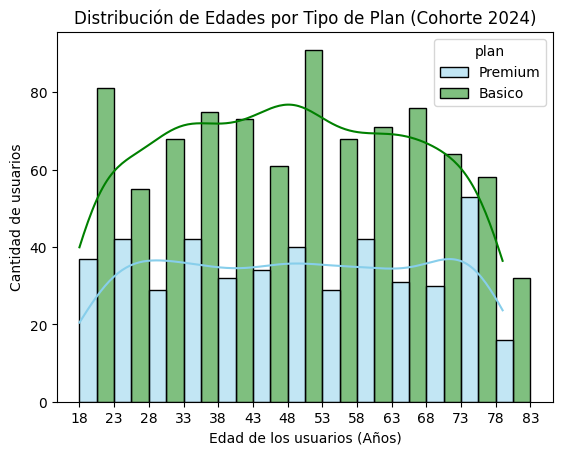

In [ ]:
# Histograma para visualizar la edad (age)
cortes_edad = np.arange(18, 84, 5)
sns.histplot(
    data=usage_2024,
    x='age',
    hue='plan',
    bins=cortes_edad,      # Usamos la lista de cortes en lugar de un número
    palette=['skyblue', 'green'],
    kde=True,
    multiple='dodge'
)

# Forzar al eje X a mostrar exactamente esos números para que tenga sentido total
plt.xticks(cortes_edad)

plt.xlabel('Edad de los usuarios (Años)')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribución de Edades por Tipo de Plan (Cohorte 2024)')
plt.show()

💡Insights:

El Plan Premium es universal (Agnóstico a la edad): La adopción del plan Premium se mantiene completamente plana y constante (entre 30~45 usuarios) en casi todos los rangos de edad. Cabe destacar un exito entre el rango 73 -78 a anios de edad.

El Plan Básico lidera en volumen con picos estratégicos: Es el motor que atrae a la masa de usuarios, destacando un pico masivo de éxito en el segmento de 48 a 53 años y una fuerte adopción inicial en jóvenes de 18 a 23 años.

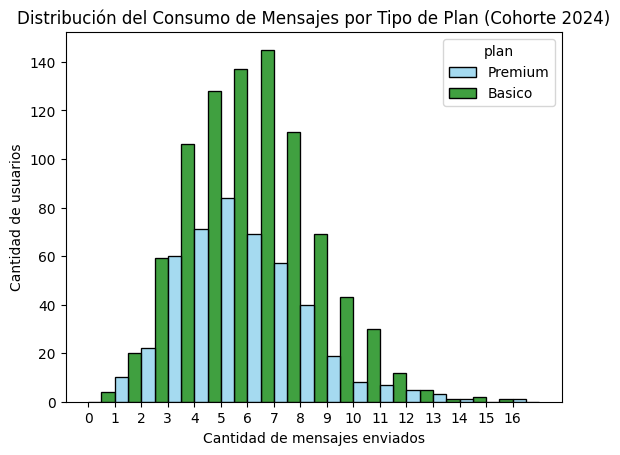

In [ ]:
# Histograma para visualizar la cant_mensajes
# Definir cortes exactos para que cada barra sea exactamente 1 mensaje
cortes_mensajes = np.arange(0, 18, 1) # [0, 1, 2, ..., 16, 17]

sns.histplot(
    data=usage_2024,
    x='cant_mensajes',
    hue='plan',
    bins=cortes_mensajes,
    palette=['skyblue', 'green'],
    kde=False,             # Desactivamos KDE porque son datos discretos y enteros
    multiple='dodge'
)

# Forzar al eje X a mostrar cada número de mensaje de 1 en 1
plt.xticks(range(0, 17))

plt.xlabel('Cantidad de mensajes enviados')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribución del Consumo de Mensajes por Tipo de Plan (Cohorte 2024)')
plt.show()


💡Insights:

El Plan Básico lidera la actividad, con un pico de consumo muy definido: Los usuarios del plan Básico (verde) no solo son más, sino que concentran su comportamiento masivamente entre los 4 y 7 mensajes, alcanzando su pico absoluto exactamente en los 7 mensajes (~145 usuarios). A partir de ahí, su consumo cae drásticamente.

El Plan Premium muestra un comportamiento más disperso y moderado: Aquí el plan Premium (azul) no es plano; sigue la misma forma de campana que el básico pero de manera más aplanada, alcanzando su pico más alto en los 5 mensajes (~84 usuarios).

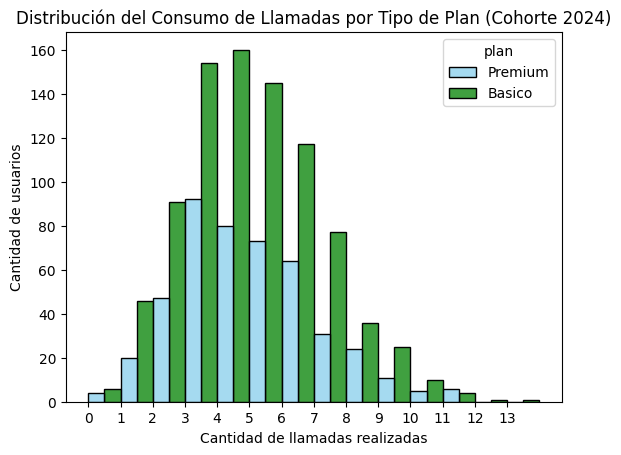

In [ ]:
# Histograma para visualizar la cant_llamadas
# Definir cortes exactos para que cada barra sea exactamente 1 llamada
cortes_llamadas = np.arange(0, 15, 1) # [0, 1, 2, ..., 13, 14]

sns.histplot(
    data=usage_2024,
    x='cant_llamadas',
    hue='plan',
    bins=cortes_llamadas,
    palette=['skyblue', 'green'],
    kde=False,             # Mantenemos apagado el KDE por ser datos enteros discretos
    multiple='dodge'
)

# Forzar al eje X a mostrar explícitamente cada número de llamada
plt.xticks(range(0, 14))

plt.xlabel('Cantidad de llamadas realizadas')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribución del Consumo de Llamadas por Tipo de Plan (Cohorte 2024)')
plt.show()


💡Insights:

El Plan Básico concentra su uso intensivo entre 4 y 6 llamadas: Los usuarios del plan Básico (verde) muestran una actividad masiva concentrada en la parte central, alcanzando su pico absoluto exactamente en las 5 llamadas (160 usuarios), seguido muy de cerca por las 4 llamadas.

El Plan Premium tiene su pico de consumo más temprano: A diferencia del plan Básico, el pico más alto de los usuarios Premium (azul) ocurre un paso antes, exactamente en las 3 llamadas (~92 usuarios). A partir de ahí, su distribución decrece de forma constante y paulatina.

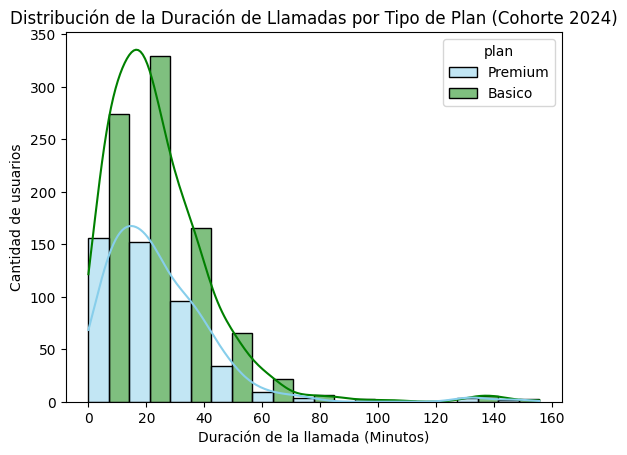

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=usage_2024,
    x='cant_minutos_llamada',
    hue='plan',
    bins=11,                  # Cantidad óptima para el rango 0-156
    palette=['skyblue', 'green'],
    kde=True,                 # Activamos la curva porque el tiempo es continuo
    multiple='dodge'
)

plt.xlabel('Duración de la llamada (Minutos)')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribución de la Duración de Llamadas por Tipo de Plan (Cohorte 2024)')
plt.show()

💡Insights:

El consumo mas importante se encuentra entre los 10 y 30 minutos. Para ambos planes, la inmensa mayoría de las llamadas mueren antes de llegar a la media hora. El plan Básico (verde) explota con su pico absoluto entre los 20 y 30 minutos (superando los 325 usuarios), mientras que el plan Premium (azul) se concentra un poco antes, estabilizándose entre los 0 y 20 minutos (~150 usuarios por barra).

Pasando los 80 minutos la gráfica se aplana por completo, pero nota ese pequeño bache o "segunda montaña" casi invisible entre los 130 y 150 minutos. Aunque son poquísimos usuarios, representan llamadas de más de dos horas.
El comportamiento general de la cohorte es realizar llamadas cortas y medianas (menos de 40 minutos), siendo el plan Básico el que genera mayor acumulación de minutos en la red. Las llamadas de larga duración (más de una hora) son eventos completamente aislados y atípicos en el negocio.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

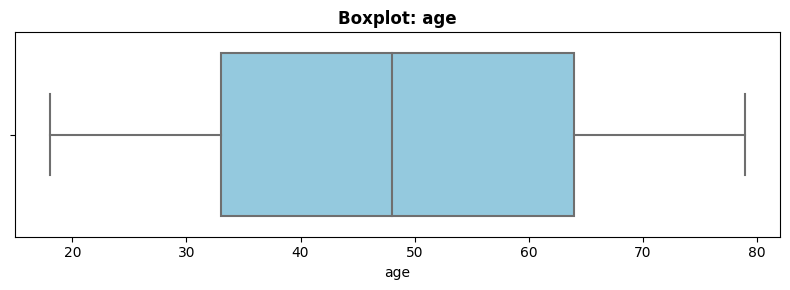

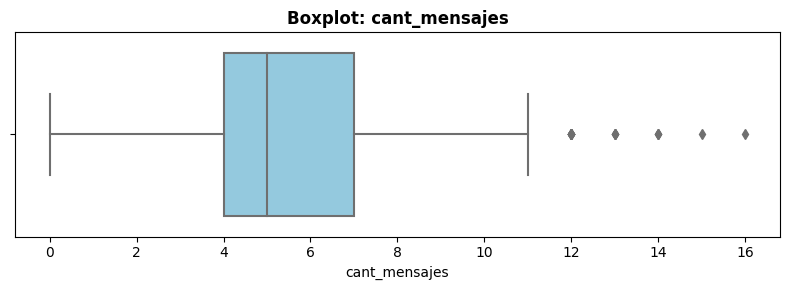

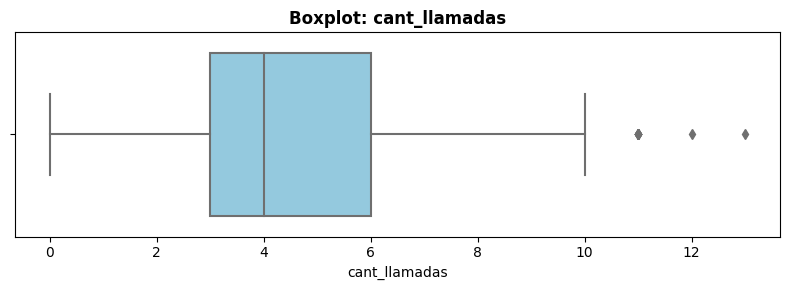

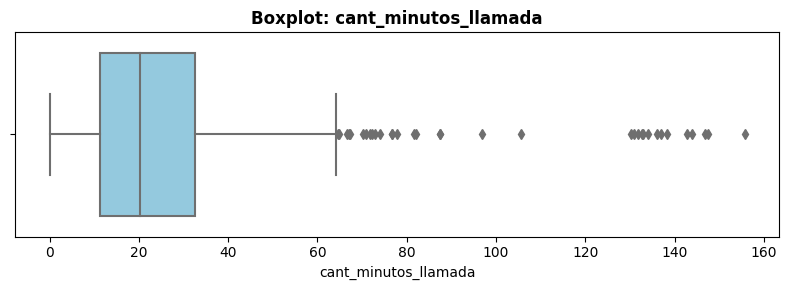

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

# Bucle for para generar los 4 boxplots automáticamente
for col in columnas_numericas:
    # Crear una nueva figura independiente para cada variable
    plt.figure(figsize=(8, 3))

    # Dibujar el boxplot horizontal
    sns.boxplot(data=usage_2024, x=col, color='skyblue')

    # Título dinámico según la columna actual
    plt.title(f'Boxplot: {col}', fontsize=12, fontweight='bold')
    plt.xlabel(col)

    # Limpiar el diseño y mostrar
    plt.tight_layout()
    plt.show()

💡Insights:
- Age: no presenta outliers
- cant_mensajes: esta sesgado a la derecha a partir de los 11 mensajes
- cant_llamadas: esta sesgado a la derecha a partir de las 10 llamadas
- cant_minutos_llamada: esta sesgado a la derecha demasiados outliers a partir de los ~62 minutos

--- Análisis de Outliers (Derecha) para: age ---
Corte de Outliers a la Derecha (Límite Superior): 110.5



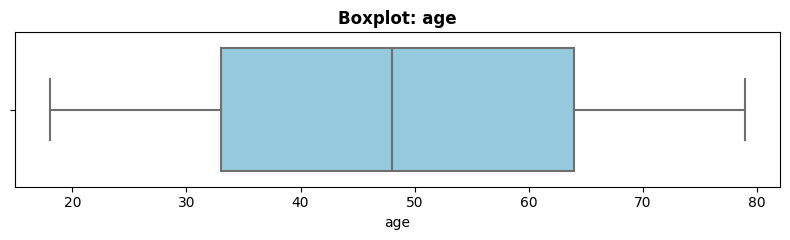



--- Análisis de Outliers (Derecha) para: cant_mensajes ---
Corte de Outliers a la Derecha (Límite Superior): 11.5



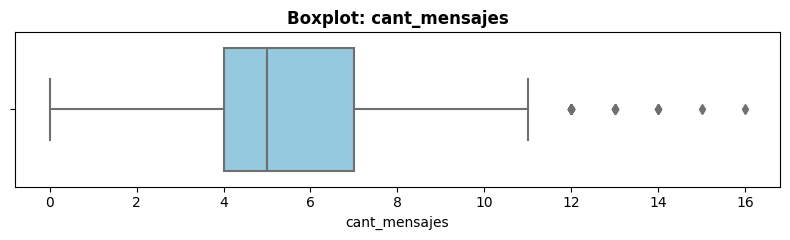



--- Análisis de Outliers (Derecha) para: cant_llamadas ---
Corte de Outliers a la Derecha (Límite Superior): 10.5



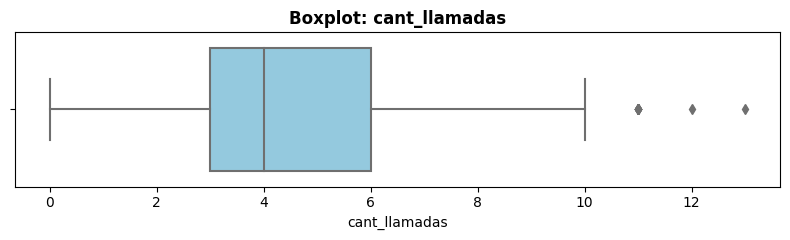



--- Análisis de Outliers (Derecha) para: cant_minutos_llamada ---
Corte de Outliers a la Derecha (Límite Superior): 64.35749999999999



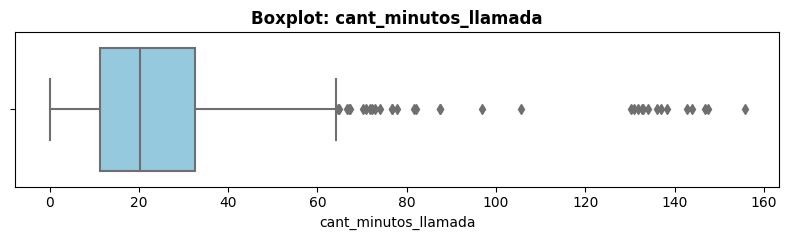

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    print(f"--- Análisis de Outliers (Derecha) para: {col} ---")

    # Calcular Q1 y Q3
    Q1 = usage_2024[col].quantile(0.25)
    Q3 = usage_2024[col].quantile(0.75)

    # Calcular IQR
    IQR = Q3 - Q1

    # Calcular únicamente el límite superior (derecho)
    limite_superior = Q3 + 1.5 * IQR

    # Imprimir métrica clave en consola
    print(f"Corte de Outliers a la Derecha (Límite Superior): {limite_superior}\n")


    # 4. Graficar el Boxplot correspondiente
    plt.figure(figsize=(8, 2.5))
    sns.boxplot(data=usage_2024, x=col, color='skyblue')
    plt.title(f'Boxplot: {col}', fontsize=12, fontweight='bold')
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

    print("\n" + "="*50 + "\n")



In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,4000.000000,4000.000000
mean,48.136000,5.523000,4.477000,23.311225
std,17.689919,2.359738,2.145139,18.169564
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.107500
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.412500
max,79.000000,17.000000,15.000000,155.690000


💡Insights:
- cant_mensajes: Límite Superior Estadístico: 11.5 mensajes. || Valor Máximo Real: 17.0 mensajes

Decisión: Mantener. Aunque estadísticamente los usuarios que envían entre 12 y 17 mensajes se consideran atípicos, un máximo de 17 mensajes no es un error de sistema ni un volumen imposible. Borrarlos significaría perder información real sobre usuarios más activos en mensajería.

- cant_llamadas: Límite Superior Estadístico: 10.5 llamadas. || Valor Máximo Real: 15.0 llamadas

Decisión: Mantener. Al igual que con los mensajes, hacer 15 llamadas en un periodo de uso es un comportamiento completamente factible para un cliente. No representa un error de captura ni afecta drásticamente la media.

- cant_minutos_llamada: Límite Superior Estadístico: ~64.36 minutos. || Valor Máximo Real: 155.69 minutos

Decisión: Filtrar o truncar. El valor máximo (155.69) es casi 7 veces más grande que la media (23.31) y más de 2.4 veces el límite superior teórico. Estos valores tan masivos van a sesgar cualquier modelo estadístico o análisis predictivo que se tenga que hacer con la duración de llamadas.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso
# Definir la lista de condiciones lógicas
condiciones = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),   # Bajo uso
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)  # Uso medio
]

# Definir las etiquetas correspondientes a cada condición
opciones = ['Bajo uso', 'Uso medio']

# Crear la columna asignando 'Alto uso' por defecto para el resto de casos
user_profile['grupo_uso'] = np.select(condiciones, opciones, default='Alto uso')

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
# Definir las condiciones lógicas para la edad
condiciones_edad = [
    (user_profile['age'] < 30),  # Joven (18 a 29 años)
    (user_profile['age'] < 60)   # Adulto (30 a 59 años)
]

# Definir las etiquetas correspondientes
opciones_edad = ['Joven', 'Adulto']

# Crear la columna asignando 'Adulto Mayor' por defecto para el resto (60 años o más)
user_profile['grupo_edad'] = np.select(condiciones_edad, opciones_edad, default='Adulto Mayor')

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

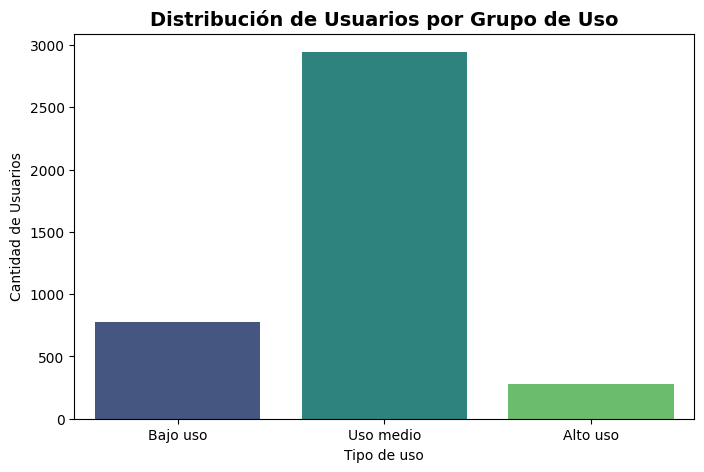

In [ ]:
# Visualización de los segmentos por uso
# Configurar el tamaño de la gráfica
plt.figure(figsize=(8, 5))

# Definir el orden lógico de las barras
orden_uso = ['Bajo uso', 'Uso medio', 'Alto uso']

# Crear el gráfico directo
sns.countplot(
    data=user_profile,
    x='grupo_uso',
    order=orden_uso,
    palette='viridis'
)

# Título y etiquetas de los ejes
plt.title('Distribución de Usuarios por Grupo de Uso', fontsize=14, fontweight='bold')
plt.xlabel('Tipo de uso')
plt.ylabel('Cantidad de Usuarios')

# Mostrar la gráfica
plt.show()

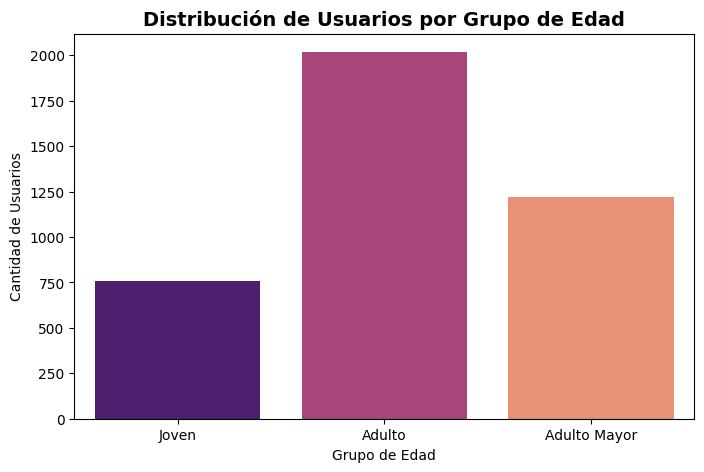

In [ ]:
# Visualización de los segmentos por edad
# Configurar el tamaño de la gráfica
plt.figure(figsize=(8, 5))

# Definir el orden lógico de las barras para las edades
orden_edad = ['Joven', 'Adulto', 'Adulto Mayor']

# Crear el gráfico directo
sns.countplot(
    data=user_profile,
    x='grupo_edad',
    order=orden_edad,
    palette='magma'  # Usamos otra paleta para diferenciarla de la gráfica anterior
)

# Título y etiquetas de los ejes
plt.title('Distribución de Usuarios por Grupo de Edad', fontsize=14, fontweight='bold')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')

# Mostrar la gráfica
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Fallas de Captura de Información (Nulos Críticos): Identificamos en el df `users` que la columna `city` presenta un 12% de valores nulos (equivalente a 480 filas de la base de 4,000 usuarios). Esto representa una pérdida de trazabilidad geográfica que afecta las estrategias de marketing localizado.

- Valores Atípicos (Outliers) por Consumo Extremo: La columna cant_minutos_llamada presentaba un fuerte sesgo a la derecha. El límite superior técnico mediante el método $IQR$ se fijó en 64.36 minutos, pero encontramos registros de hasta 155.69 minutos. Estos valores extremos representaban un comportamiento atípico que inflaba artificialmente la media general del consumo ($\mu = 23.31$ minutos).

- Ausencia de Actividad vs. Errores: En el df `usage`, las columnas `duration` (55% de nulos) y `length` (45% de nulos) reflejan la inactividad de los usuarios en ciertos servicios (clientes que envían mensajes pero no llaman, o viceversa). Por su parte, el 88% de nulos en churn_date no es un problema, sino una métrica positiva: representa que el 88% de nuestra base sigue activa y retenida.


🔍 **Segmentos por Edad**
- Por Nivel de Uso (grupo_uso):

Uso Medio (El Motor): Dominio absoluto con casi 2,950 usuarios. Tienen un comportamiento balanceado e indexado que respeta los límites de la red.

Bajo Uso: ~780 usuarios que registran consumos mínimos (menos de 5 llamadas y 5 mensajes).

Alto Uso: Un grupo exclusivo de ~300 usuarios que satura de forma constante los servicios.

- Por Etapa de Vida (grupo_edad):

Adultos (30-59 años): El segmento dominante con más de 2,000 usuarios.

Adultos Mayores (60+ años): Una presencia sorpresivamente robusta de ~1,225 usuarios, superando con claridad al segmento Joven (<30 años) que apenas alcanza los ~760 usuarios.


📊 **Segmentos por Nivel de Uso**
- El Segmento Adulto de Uso Medio: Representa la combinación perfecta de volumen y estabilidad financiera. Al superar los 2,000 usuarios, es el grupo que sostiene la predictibilidad de los ingresos mensuales recurrentes de la compañía.
- El Segmento Premium Ineficiente: Aquellos usuarios en plan Premium cuyo comportamiento visualizado se estabiliza entre los 0 y 20 minutos. Al pagar la tarifa más alta pero consumir menos recursos que el promedio, representan el margen de utilidad neta más limpio para el negocio.
- El Segmento de la Tercera Edad (Adulto Mayor): Con 1,225 clientes, es una mina de oro para la retención. Son usuarios estables que, si reciben una oferta paquetizada adecuada, garantizan un ciclo de vida del cliente prolongado.


➡️ **Outliers e implicaciones**

- Encontramos un patrón de "hiper-conectados" concentrado en llamadas de larga duración que van de los 130 a los 155 minutos
- Implicación Técnica: Generan un riesgo de saturación en las celdas de red durante horas pico si muchos coinciden.
- Implicación Comercial: Representan una fuga de valor. Si estos usuarios se encuentran actualmente bajo un plan comercial plano o Básico, están consumiendo infraestructura de manera desproporcionada respecto a lo que pagan. No deben ser eliminados del negocio, sino migrados a esquemas comerciales donde su sobreconsumo se monetice.



💡 **Recomendaciones**
- Estrategia de Blindaje contra el Churn (Retención Preventiva):
Sabemos que el 12% de los usuarios ya canceló el servicio (basado en el 12% de datos con fecha en churn_date). Debes proponer la creación de un Modelo de Alerta Temprana. Si un usuario del segmento "Uso Medio" o "Adulto" empieza a mostrar un comportamiento que emula al grupo de "Bajo Uso" (caída drástica en llamadas o nulos consecutivos en la duración), el sistema debe disparar automáticamente un beneficio o descuento de retención antes de que decida irse.

- Rediseño del Formulario de Captura Digital (Solución al 12% de Nulos en city):
La pérdida del 12% de los datos geográficos en la columna city frena las campañas de expansión local. La recomendación es implementar una validación obligatoria por API (como Google Maps) en el flujo de registro o actualización de datos. Para la base de datos actual que ya tiene ese vacío (480 usuarios), se puede lanzar una campaña de notificación push o SMS que regale un pequeño beneficio (ej. 10 mensajes gratis) a cambio de que el usuario complete su perfil actualizando su ciudad.

- Creación del "Plan Familiar / Parejas" (Monetización de los Nulos Cruzados):
Detectamos que el 55% de los usuarios no llama (duration nulo) y el 45% no envía mensajes (length nulo). Esto nos dice que los usuarios tienen canales de comunicación hiper-específicos. Podemos crear un Plan Flexible o Modular, donde el cliente configure su plan según su perfil real (ej. un plan 100% voz / 0 mensajes para adultos mayores, o un plan 100% datos y mensajes / 0 voz para jóvenes), evitando que sientan que pagan por servicios que dejan en total inactividad.

- Estrategia de "Tarifa de Congestión" o Penalización por Exceso para el Plan Básico:
Dado que el Plan Básico es el que satura la red en el bloque de 20 a 30 minutos, se debe eliminar la posibilidad de llamadas ilimitadas en este esquema. Se puede establecer una política de "Corte o Cobro por Minuto Adicional" a partir del minuto 40. Esto empujará de forma orgánica a los usuarios que rozan los límites a adquirir el Plan Premium, incrementando el ARPU (Average Revenue Per User) sin necesidad de invertir en marketing externo.
- Lanzar un Plan Senior Dedicado: Diseñar un paquete enfocado en los 1,225 Adultos Mayores, ofreciendo asistencia prioritaria o números frecuentes de voz gratuitos, asegurando la lealtad del segundo segmento más grande de la empresa.

- Estrategia de Up-selling "Micro-Upgrades": Dirigirse a los ~780 usuarios de Bajo Uso ofreciéndoles pequeños paquetes de datos o mensajes a un costo marginal mínimo para forzar su migración orgánica hacia el segmento de Uso Medio.

- Empaquetamiento para Outliers: Aislar comercialmente a los ~300 usuarios de Alto Uso y a los clientes que superan el límite de 64.36 minutos por llamada. Se les debe restringir el abuso en planes ordinarios y ofrecerles un plan de alta gama con un costo de suscripción significativamente mayor.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`